# Visualizing Dataset

In [15]:
import pandas as pd
import random

import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import cv2

from pycocotools.coco import COCO
from pycocotools import mask as mask_utils

In [16]:
COCO_DATASET_DIR = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D3")
IMAGES_DIR = COCO_DATASET_DIR / "images"
ANNOTATIONS_DIR = COCO_DATASET_DIR / "annotations"


train_images_dir = IMAGES_DIR / "train"
val_images_dir = IMAGES_DIR / "val"
test_images_dir = IMAGES_DIR / "test"

# M1
train_ann_m1_dir = ANNOTATIONS_DIR / "instances_train_m1.json"
val_ann_m1_dir = ANNOTATIONS_DIR / "instances_val_m1.json"
test_ann_m1_dir = ANNOTATIONS_DIR / "instances_test_m1.json"

# M2
train_ann_m2_dir = ANNOTATIONS_DIR / "instances_train_m2.json"
val_ann_m2_dir = ANNOTATIONS_DIR / "instances_val_m2.json"
test_ann_m2_dir = ANNOTATIONS_DIR / "instances_test_m2.json"

In [29]:
# unify vars 
ANN_M1_DIR = train_ann_m1_dir
ANN_M2_DIR = train_ann_m2_dir

IMG_DIR = train_images_dir

In [30]:
with open (ANN_M1_DIR, "r") as f:
    annotations_m1 = json.load(f)

with open (ANN_M2_DIR, "r") as f:
    annotations_m2 = json.load(f)

print("Annotations Keys:")
print(annotations_m1.keys())

categories_id_m1 = [category_object["id"] for category_object in annotations_m1["categories"]]
categories_id_m2 = [category_object["id"] for category_object in annotations_m2["categories"]]

categories_names_m1 =  [category_object["name"] for category_object in annotations_m1["categories"]]
categories_names_m2 =  [category_object["name"] for category_object in annotations_m2["categories"]]

print()
print("Category IDs:")
print("M1: ", categories_id_m1)
print("M2: ", categories_id_m2)

print()
print("Category names:")
print("M1: ", categories_names_m1)
print("M2: ", categories_names_m2)

M1_CATEGORY_MAP = {}
M2_CATEGORY_MAP = {}

for category_id, category_name in zip(categories_id_m1, categories_names_m1):
    M1_CATEGORY_MAP[category_id] = category_name

for category_id, category_name in zip(categories_id_m2, categories_names_m2):
    M2_CATEGORY_MAP[category_id] = category_name

print()
print("Maps:")
print("M1: ", M1_CATEGORY_MAP)
print("M2: ", M2_CATEGORY_MAP)

Annotations Keys:
dict_keys(['images', 'annotations', 'categories'])

Category IDs:
M1:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
M2:  [1000, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Category names:
M1:  ['81', '84', '124', '147', '153', '184', '196', '198', '206', '225']
M2:  ['0_1000', '1_81', '1_84', '1_124', '1_147', '1_153', '1_184', '1_196', '1_198', '1_206', '1_225']

Maps:
M1:  {1: '81', 2: '84', 3: '124', 4: '147', 5: '153', 6: '184', 7: '196', 8: '198', 9: '206', 10: '225'}
M2:  {1000: '0_1000', 1: '1_81', 2: '1_84', 3: '1_124', 4: '1_147', 5: '1_153', 6: '1_184', 7: '1_196', 8: '1_198', 9: '1_206', 10: '1_225'}


In [48]:
m1_classes = len(categories_id_m1)
m2_classes = len(categories_id_m2)

#colors = [cm.get_cmap("Reds")(i)[:3] for i in range(m1_classes)]
#m1_colors = [cm.get_cmap("Reds")(i / (m1_classes - 1))[:3] for i in range(m1_classes)]
m1_colors = [ [int(x * 255) for x in plt.get_cmap("Reds")(i / (m1_classes - 1))[:3]] for i in range(m1_classes) ]
m2_colors = [ [int(x * 255) for x in plt.get_cmap("Reds")(i / (m2_classes - 1))[:3]] for i in range(m2_classes) ]
m2_colors[-1] = [0, 0, 255] # facade - blue, for distinction

print("Colors:")
print("M1: ", m1_colors)
print("M2: ", m2_colors)

COLOR_MAP_M1 = {}
COLOR_MAP_M2 = {}

for cat_id in categories_id_m1:
    try:
        COLOR_MAP_M1[cat_id] = m1_colors[cat_id - 1]
    except IndexError:
        try:
            COLOR_MAP_M1[cat_id] = m1_colors[-1]
        except:
            pass

for cat_id in categories_id_m2:
    try:
        COLOR_MAP_M2[cat_id] = m2_colors[cat_id - 1]
    except IndexError:
        try:
            COLOR_MAP_M2[cat_id] = m2_colors[-1]
        except:
            pass

print()
print("COLOR MAPS:")
print("M1: ", COLOR_MAP_M1)
print("M2: ", COLOR_MAP_M2)

Colors:
M1:  [[255, 245, 240], [254, 226, 213], [252, 195, 172], [252, 159, 129], [251, 124, 92], [245, 84, 60], [227, 47, 39], [193, 21, 27], [157, 13, 20], [103, 0, 12]]
M2:  [[255, 245, 240], [254, 228, 216], [252, 201, 180], [252, 171, 142], [251, 138, 106], [250, 105, 73], [241, 68, 50], [216, 37, 34], [187, 20, 25], [151, 11, 19], [0, 0, 255]]

COLOR MAPS:
M1:  {1: [255, 245, 240], 2: [254, 226, 213], 3: [252, 195, 172], 4: [252, 159, 129], 5: [251, 124, 92], 6: [245, 84, 60], 7: [227, 47, 39], 8: [193, 21, 27], 9: [157, 13, 20], 10: [103, 0, 12]}
M2:  {1000: [0, 0, 255], 1: [255, 245, 240], 2: [254, 228, 216], 3: [252, 201, 180], 4: [252, 171, 142], 5: [251, 138, 106], 6: [250, 105, 73], 7: [241, 68, 50], 8: [216, 37, 34], 9: [187, 20, 25], 10: [151, 11, 19]}


In [52]:

def check_consitency(annotations_dir, images_dir):
    
    coco = COCO(annotations_dir)

    img_ids = coco.getImgIds()
    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)

    print("Images:", len(img_ids))
    print("Categories:", [(c["id"], c["name"]) for c in cats])

    # annotation number per class
    for c in cats:
        ann_ids = coco.getAnnIds(catIds=[c["id"]])
        print(f"Annotations for {c['name']}: {len(ann_ids)}")

    missing = 0
    for i in random.sample(img_ids, min(50, len(img_ids))):
        f = coco.loadImgs([i])[0]["file_name"]
        if not os.path.exists(os.path.join(images_dir, f)):
            missing += 1
    print("Missing files in sample:", missing)


print()
print("Entry Stats:")
print("M1:")
check_consitency(ANN_M1_DIR, IMG_DIR)
print()
print("M2")
check_consitency(ANN_M2_DIR, IMG_DIR)


Entry Stats:
M1:
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Images: 836
Categories: [(1, '81'), (2, '84'), (3, '124'), (4, '147'), (5, '153'), (6, '184'), (7, '196'), (8, '198'), (9, '206'), (10, '225')]
Annotations for 81: 911
Annotations for 84: 1342
Annotations for 124: 794
Annotations for 147: 958
Annotations for 153: 995
Annotations for 184: 675
Annotations for 196: 444
Annotations for 198: 1385
Annotations for 206: 1661
Annotations for 225: 0
Missing files in sample: 0

M2
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
Images: 836
Categories: [(1000, '0_1000'), (1, '1_81'), (2, '1_84'), (3, '1_124'), (4, '1_147'), (5, '1_153'), (6, '1_184'), (7, '1_196'), (8, '1_198'), (9, '1_206'), (10, '1_225')]
Annotations for 0_1000: 8350
Annotations for 1_81: 16011
Annotations for 1_84: 20283
Annotations for 1_124: 6258
Annotations for 1_147: 13914
Annotations for 1_153: 0
Annotations for 1_184: 2347
Annotations for

In [ ]:
import numpy as np
import random 
from PIL import Image

def draw_bbox(ax, bbox, category_name, color="red", linewidth=1):
    x, y, w, h = bbox
    
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=linewidth)
    ax.add_patch(rect)
    
    text_bbox_style = dict(
        facecolor="black",
        edgecolor='none',
        alpha=0.7,
        pad=1.0
    )
    

    ax.text(
        x, y, 
        category_name, 
        color='white',
        fontsize=4, 
        fontweight='bold',
        va='bottom',  
        ha='left',   
        bbox=text_bbox_style  
    )


def display_annotations(image, image_annotations, ann_type="m1"):

    H, W = image.shape[:2]
    overlay = image.astype(np.float32).copy()
    alpha = 0.4

    for annotation_object in image_annotations:
        m = mask_utils.decode(annotation_object["segmentation"]).astype(bool)

        if m.shape[0] != H or m.shape[1] != W:
            continue
        category_id = annotation_object["category_id"]
        
        if ann_type == "m1":
            color = COLOR_MAP_M1[category_id]
        else:
            color = COLOR_MAP_M2[category_id]

        color = np.array(color).astype(np.float32)

        overlay[m] = (1 - alpha) * overlay[m] + alpha * color
        out = np.clip(overlay, 0, 255).astype(np.uint8)
            
    return out

def show_random_images(annotation_dir, images_dir, ann_type="m1", n=3):
    coco = COCO(annotation_dir)

    img_ids = coco.getImgIds()
    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)

    rng = np.random.default_rng(0)
    random.seed(0)

    for _ in range(n):
        image_id = random.choice(img_ids)
        image_info = coco.loadImgs([image_id])[0]
        path = os.path.join(images_dir, image_info["file_name"])
        image = np.array(Image.open(path).convert("RGB"))
        ann_ids = coco.getAnnIds(imgIds=[image_id])
        anns = coco.loadAnns(ann_ids)

        fig, ax = plt.subplots(figsize=(12,10))
        #fig.suptitle(f"image ID: {image_id}", fontsize=16, fontweight='bold')

        #ax1 = plt.subplot(1,2,1)
        #ax1.set_title(f"Annotations OFF")
        #ax1.imshow(image)
        #ax1.axis("off")

        annotated_image = display_annotations(image, anns, ann_type=ann_type)
        #ax2 = plt.subplot(1,2,2)
        ax2 = ax
        ax2.set_title(f"image = {image_id}")
        out = annotated_image
        ax2.imshow(out)
        ax2.axis("off")
        plt.tight_layout()
        
        for a in anns:
            category_id = a["category_id"]
            if ann_type == "m1":
                category_name = M1_CATEGORY_MAP[category_id]
                color = COLOR_MAP_M1[category_id]
            else:
                category_name = M2_CATEGORY_MAP[category_id]
                color = COLOR_MAP_M2[category_id]

            color = np.array(color).astype(np.float32) / 255
            draw_bbox(ax2, a["bbox"], category_name, color=color, linewidth=1)

        plt.show()


loading annotations into memory...
Done (t=0.48s)
creating index...
index created!


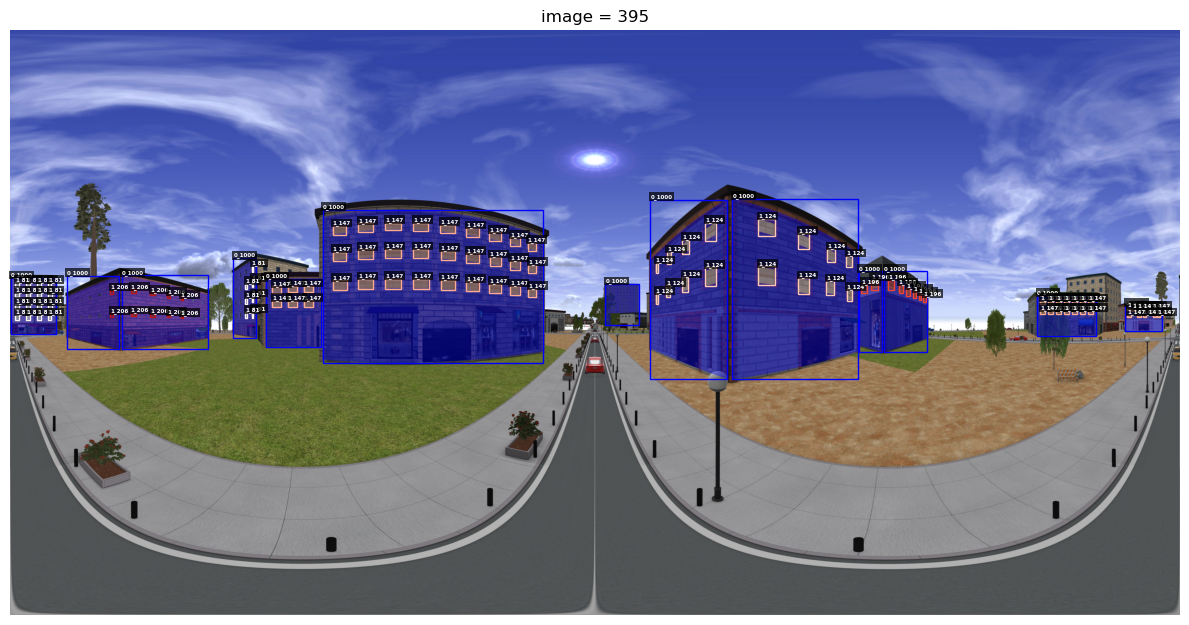

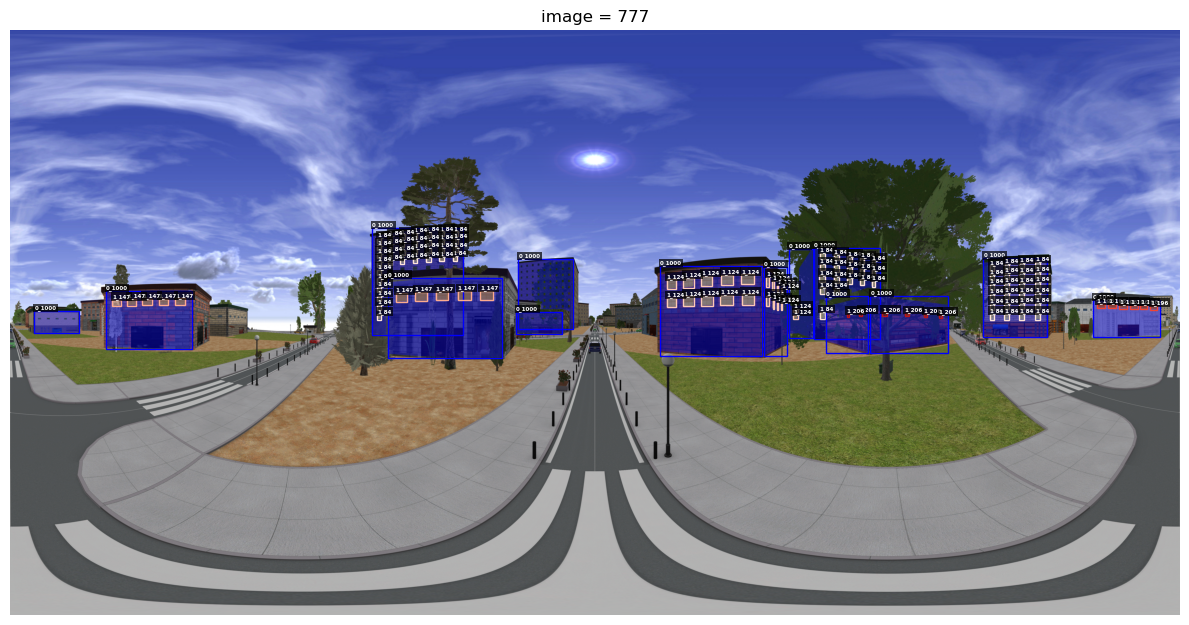

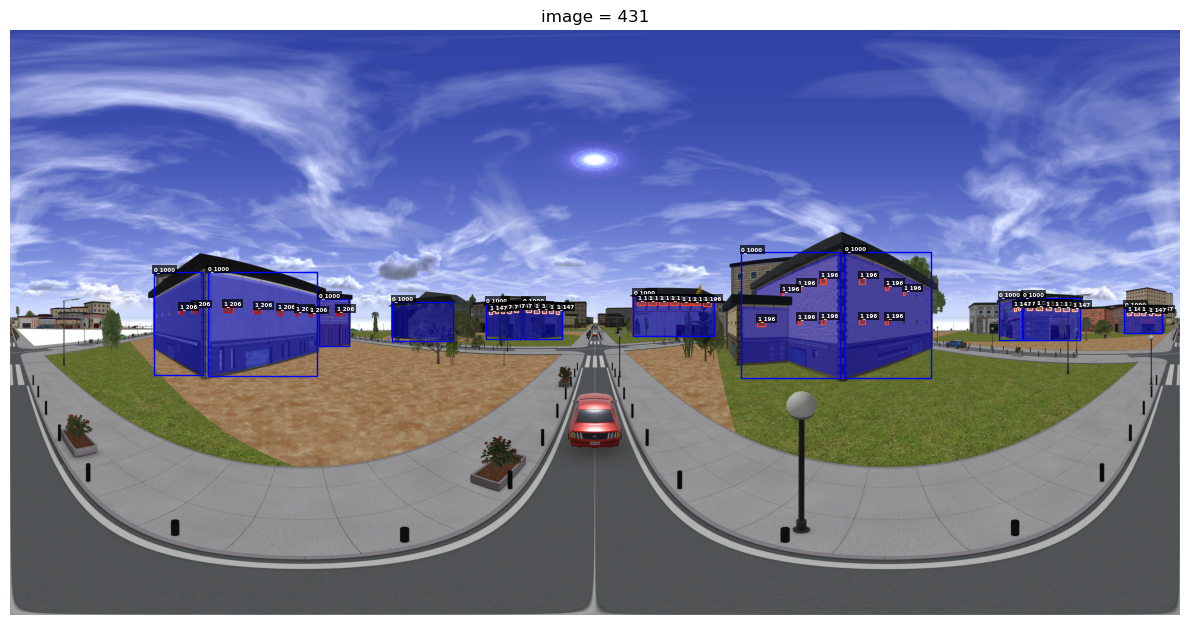

In [77]:
n = 3
show_random_images(ANN_M2_DIR, IMG_DIR, "m2", n)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


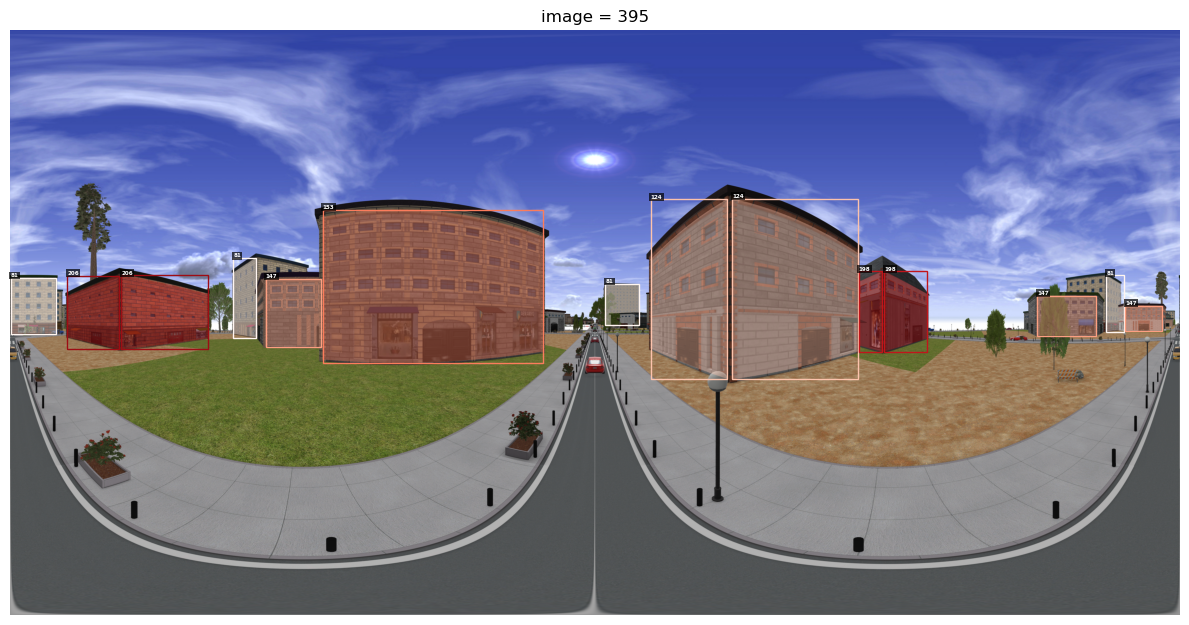

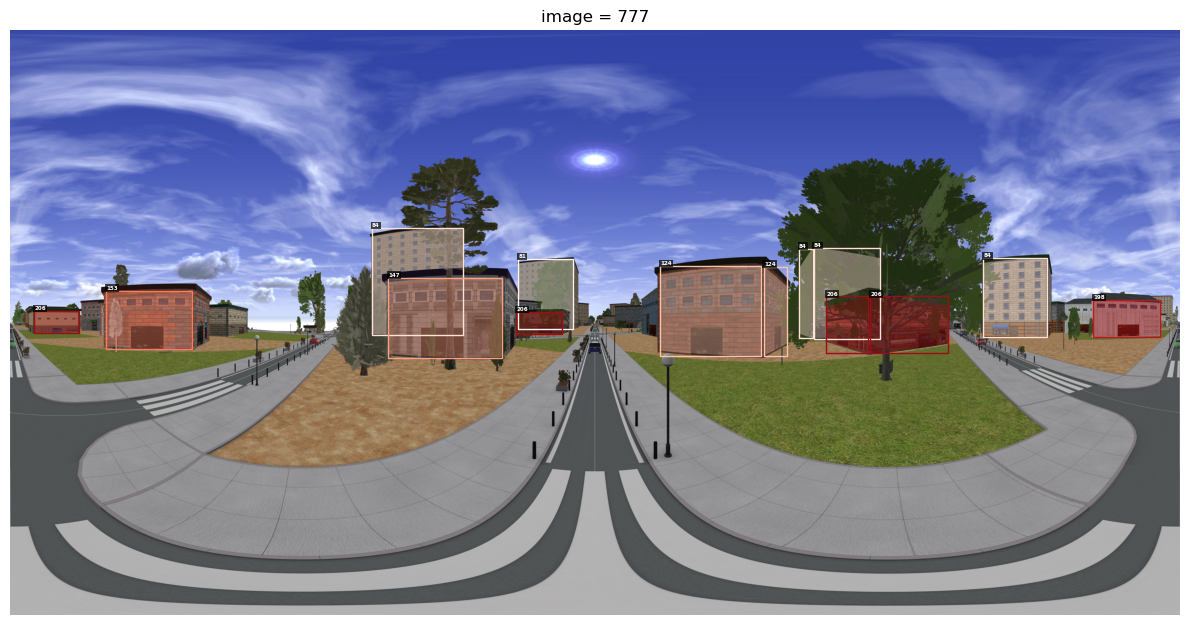

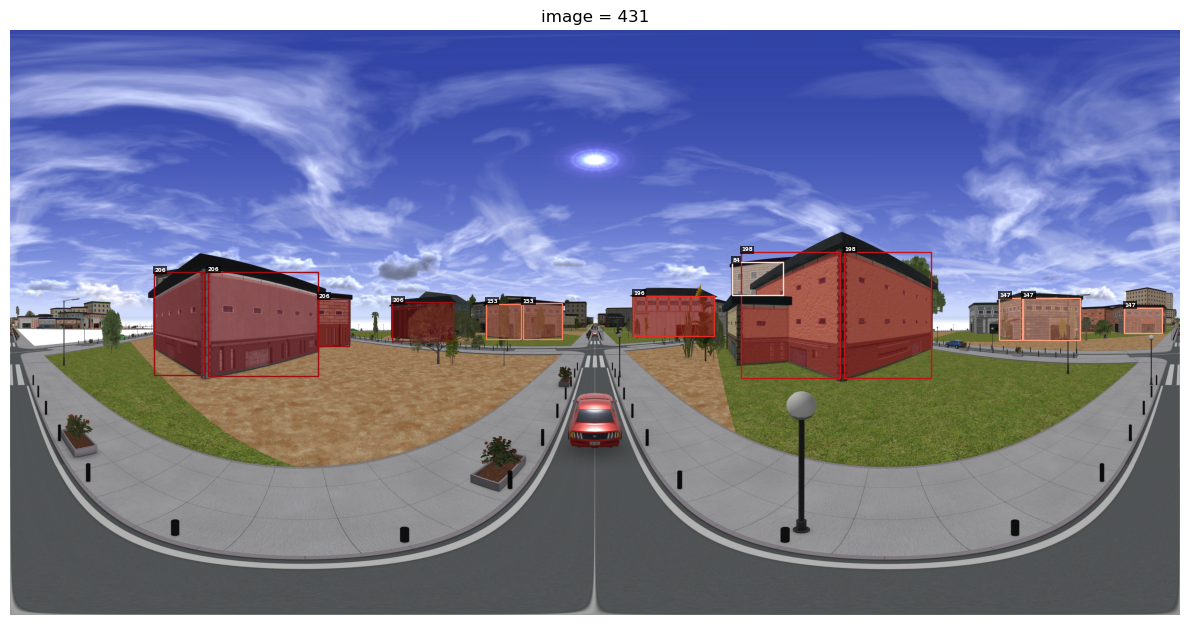

In [78]:
show_random_images(ANN_M1_DIR, IMG_DIR, "m1", n)

In [79]:
COCO_DATASET_DIR = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D4")
IMAGES_DIR = COCO_DATASET_DIR / "images"
ANNOTATIONS_DIR = COCO_DATASET_DIR / "annotations"

new_images_dir = IMAGES_DIR / "train"

# M1
new_ann_m1_dir = ANNOTATIONS_DIR / "instances_train_m1.json"

# M2
new_ann_m2_dir = ANNOTATIONS_DIR / "instances_train_m2.json"



loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


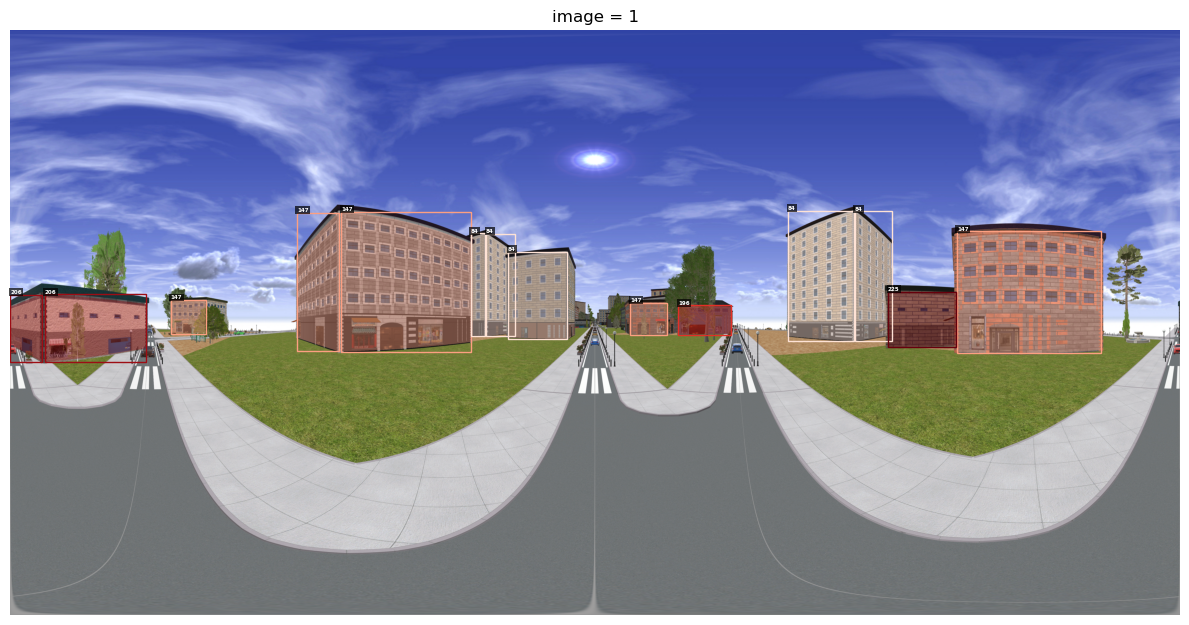

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


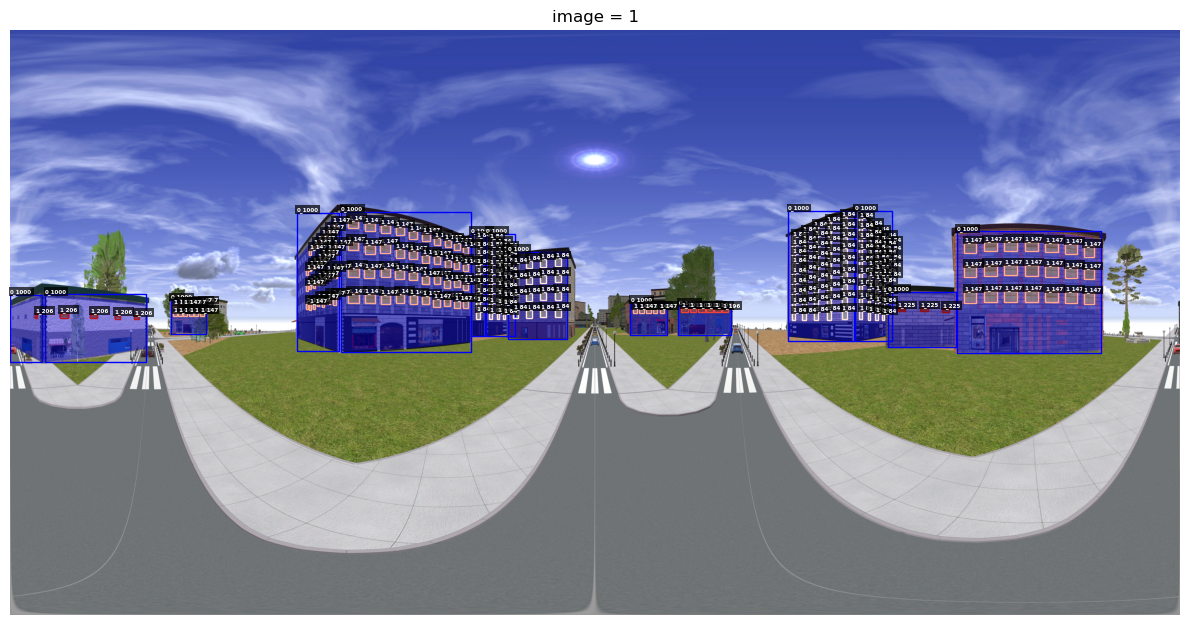

In [81]:
n = 1

show_random_images(new_ann_m1_dir, new_images_dir, "m1", n)
show_random_images(new_ann_m2_dir, new_images_dir, "m2", n)